# MINI PROJECT 2

In [1]:
import findspark
findspark.init()

In [2]:
from pyspark.sql import SparkSession
from pyspark.sql.types import * 
import pyspark.sql.functions as F
import matplotlib.pyplot as plt

spark = SparkSession.builder \
    .master("local[*]") \
    .appName("BankMarketingEDA") \
    .getOrCreate()


# Read source file

In [3]:
# Create a SparkSession
spark = SparkSession.builder.appName("BankMarketingEDA").getOrCreate()

# Load the data
data = spark.read.csv(r"C:\Users\santh\Downloads\XYZ_Bank_Deposit_Data_Classification.csv", header=True, inferSchema=True,sep=';')


In [4]:
# Renaming columns with special characters or spaces
data = data.withColumnRenamed("emp.var.rate", "emp_var_rate") \
    .withColumnRenamed("cons.price.idx", "cons_price_idx") \
    .withColumnRenamed("cons.conf.idx", "cons_conf_idx") \
    .withColumnRenamed("nr.employed", "nr_employed") \
    .withColumnRenamed("euribor3m", "euribor_3m")

In [5]:
from pyspark.sql.functions import when

data = data.withColumn("y", when(data["y"] == "yes", 1).otherwise(0))

# Show sample data

In [6]:
data.show(5)

+---+---------+-------+-----------+-------+-------+----+---------+-----+-----------+--------+--------+-----+--------+-----------+------------+--------------+-------------+----------+-----------+---+
|age|      job|marital|  education|default|housing|loan|  contact|month|day_of_week|duration|campaign|pdays|previous|   poutcome|emp_var_rate|cons_price_idx|cons_conf_idx|euribor_3m|nr_employed|  y|
+---+---------+-------+-----------+-------+-------+----+---------+-----+-----------+--------+--------+-----+--------+-----------+------------+--------------+-------------+----------+-----------+---+
| 56|housemaid|married|   basic.4y|     no|     no|  no|telephone|  may|        mon|     261|       1|  999|       0|nonexistent|         1.1|        93.994|        -36.4|     4.857|     5191.0|  0|
| 57| services|married|high.school|unknown|     no|  no|telephone|  may|        mon|     149|       1|  999|       0|nonexistent|         1.1|        93.994|        -36.4|     4.857|     5191.0|  0|
| 37|

# Data types of columns

In [7]:
# Display the schema and first few rows
data.printSchema()
data.show(5, truncate=False)

root
 |-- age: integer (nullable = true)
 |-- job: string (nullable = true)
 |-- marital: string (nullable = true)
 |-- education: string (nullable = true)
 |-- default: string (nullable = true)
 |-- housing: string (nullable = true)
 |-- loan: string (nullable = true)
 |-- contact: string (nullable = true)
 |-- month: string (nullable = true)
 |-- day_of_week: string (nullable = true)
 |-- duration: integer (nullable = true)
 |-- campaign: integer (nullable = true)
 |-- pdays: integer (nullable = true)
 |-- previous: integer (nullable = true)
 |-- poutcome: string (nullable = true)
 |-- emp_var_rate: double (nullable = true)
 |-- cons_price_idx: double (nullable = true)
 |-- cons_conf_idx: double (nullable = true)
 |-- euribor_3m: double (nullable = true)
 |-- nr_employed: double (nullable = true)
 |-- y: integer (nullable = false)

+---+---------+-------+-----------+-------+-------+----+---------+-----+-----------+--------+--------+-----+--------+-----------+------------+------------

# Summary statistics

In [8]:
# For numeric columns, compute summary statistics
numeric_features = [t[0] for t in data.dtypes if t[1] in('int','double')]
data.select(numeric_features).describe().toPandas().transpose()

,0,1,2,3,4
summary,count,mean,stddev,min,max
age,41188,40.02406040594348,10.421249980934057,17,98
duration,41188,258.2850101971448,259.279248836465,0,4918
campaign,41188,2.567592502670681,2.7700135429023245,1,56
pdays,41188,962.4754540157328,186.91090734474085,0,999
previous,41188,0.17296299893172767,0.4949010798392899,0,7
emp_var_rate,41188,0.0818855006318764,1.5709597405170317,-3.4,1.4
cons_price_idx,41188,93.57566436831112,0.5788400489540239,92.201,94.767
cons_conf_idx,41188,-40.50260027191374,4.628197856174587,-50.8,-26.9
euribor_3m,41188,3.6212908128581733,1.734447404851258,0.634,5.045


In [9]:
from pyspark.sql.functions import col, asc,desc
from pyspark.sql.functions import count, countDistinct, exp

# For categorical columns, compute custom statistics like count of distinct values and frequency of each category
categorical_features = [t[0] for t in data.dtypes if t[1] == 'string']

# A list to hold the stats for each categorical feature
categorical_stats = []

# Calculate the custom stats for each categorical column
for categoricalCol in categorical_features:
    # Count of distinct values
    distinct_count = data.agg(countDistinct(col(categoricalCol)).alias('distinct_count')).collect()[0]['distinct_count']
    # Most frequent category and its count
    top_category = data.groupBy(categoricalCol).count().orderBy('count', ascending=False).first()
    # Store the stats
    categorical_stats.append((categoricalCol, distinct_count, top_category[categoricalCol], top_category['count']))

categorical_stats_df = spark.createDataFrame(categorical_stats, ["Column", "Distinct Count", "Top Category", "Frequency"])

# Show the DataFrame
categorical_stats_df.show()

# Convert to Pandas DataFrame for better visualization if needed
categorical_stats_pd = categorical_stats_df.toPandas().transpose()


+-----------+--------------+-----------------+---------+
|     Column|Distinct Count|     Top Category|Frequency|
+-----------+--------------+-----------------+---------+
|        job|            12|           admin.|    10422|
|    marital|             4|          married|    24928|
|  education|             8|university.degree|    12168|
|    default|             3|               no|    32588|
|    housing|             3|              yes|    21576|
|       loan|             3|               no|    33950|
|    contact|             2|         cellular|    26144|
|      month|            10|              may|    13769|
|day_of_week|             5|              thu|     8623|
|   poutcome|             3|      nonexistent|    35563|
+-----------+--------------+-----------------+---------+



In [10]:
# Univariate analysis for numerical columns (e.g., age, duration)
data.select("age", "duration").summary("count", "min", "max", "mean", "stddev").show()


+-------+------------------+-----------------+
|summary|               age|         duration|
+-------+------------------+-----------------+
|  count|             41188|            41188|
|    min|                17|                0|
|    max|                98|             4918|
|   mean| 40.02406040594348|258.2850101971448|
| stddev|10.421249980934057| 259.279248836465|
+-------+------------------+-----------------+



In [11]:
# Univariate analysis for categorical columns (e.g., job, marital)
data.groupBy("job").count().show()
data.groupBy("marital").count().show()

+-------------+-----+
|          job|count|
+-------------+-----+
|   management| 2924|
|      retired| 1720|
|      unknown|  330|
|self-employed| 1421|
|      student|  875|
|  blue-collar| 9254|
| entrepreneur| 1456|
|       admin.|10422|
|   technician| 6743|
|     services| 3969|
|    housemaid| 1060|
|   unemployed| 1014|
+-------------+-----+

+--------+-----+
| marital|count|
+--------+-----+
| unknown|   80|
|divorced| 4612|
| married|24928|
|  single|11568|
+--------+-----+



# Target variable distribution

In [12]:
# Bivariate analysis - relationship between 'y' and other variables
data.groupBy("y").agg(F.mean("age"), F.mean("duration")).show()


+---+------------------+------------------+
|  y|          avg(age)|     avg(duration)|
+---+------------------+------------------+
|  1| 40.91314655172414| 553.1911637931034|
|  0|39.911185290576775|220.84480682937507|
+---+------------------+------------------+



# Check for null values

In [13]:
# Handling missing data
missing_count = data.select([F.count(F.when(F.isnan(c) | F.isnull(c), c)).alias(c) for c in data.columns])
missing_count.show()

+---+---+-------+---------+-------+-------+----+-------+-----+-----------+--------+--------+-----+--------+--------+------------+--------------+-------------+----------+-----------+---+
|age|job|marital|education|default|housing|loan|contact|month|day_of_week|duration|campaign|pdays|previous|poutcome|emp_var_rate|cons_price_idx|cons_conf_idx|euribor_3m|nr_employed|  y|
+---+---+-------+---------+-------+-------+----+-------+-----+-----------+--------+--------+-----+--------+--------+------------+--------------+-------------+----------+-----------+---+
|  0|  0|      0|        0|      0|      0|   0|      0|    0|          0|       0|       0|    0|       0|       0|           0|             0|            0|         0|          0|  0|
+---+---+-------+---------+-------+-------+----+-------+-----+-----------+--------+--------+-----+--------+--------+------------+--------------+-------------+----------+-----------+---+



In [14]:
Dict_Null = {col:data.filter(data[col].isNull()).count() for col in data.columns}
Dict_Null

{'age': 0,
 'job': 0,
 'marital': 0,
 'education': 0,
 'default': 0,
 'housing': 0,
 'loan': 0,
 'contact': 0,
 'month': 0,
 'day_of_week': 0,
 'duration': 0,
 'campaign': 0,
 'pdays': 0,
 'previous': 0,
 'poutcome': 0,
 'emp_var_rate': 0,
 'cons_price_idx': 0,
 'cons_conf_idx': 0,
 'euribor_3m': 0,
 'nr_employed': 0,
 'y': 0}

# Distribution of features

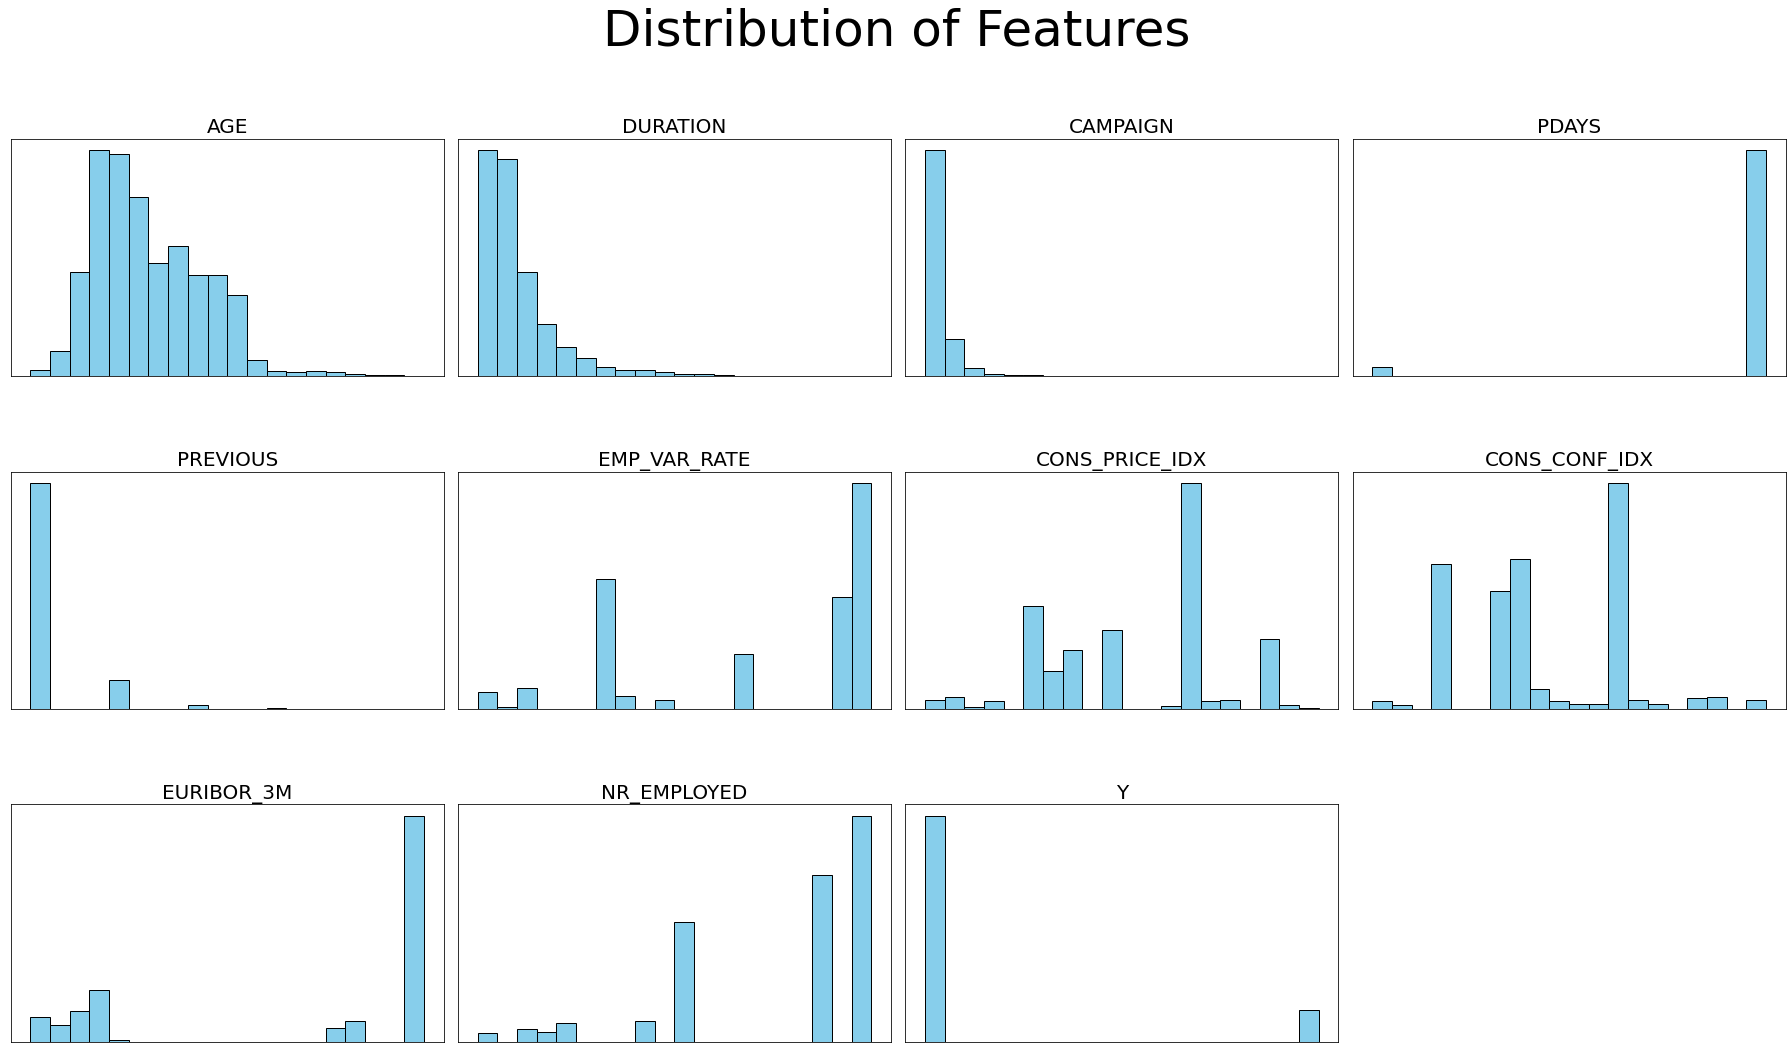

In [15]:
# Distribution of Features
import matplotlib.pyplot as plt

pandas_df = data.sample(fraction=0.1, withReplacement=False).toPandas()

# Define the figure for plotting
fig = plt.figure(figsize=(25, 15))
st = fig.suptitle("Distribution of Features", fontsize=50, verticalalignment='center')

# Create a histogram for each numeric column in the DataFrame
numeric_columns = [column for (column, dtype) in data.dtypes if dtype in ['int', 'double']]
for i, col in enumerate(numeric_columns, 1):
    ax = fig.add_subplot(3, 4, i)
    ax.hist(pandas_df[col].dropna(), bins=20, color='skyblue', edgecolor='black')  
    ax.set_title(col.upper(), fontsize=20)
    ax.set_xticks([])
    ax.set_yticks([])

# Adjust layout and show plot
plt.tight_layout()
st.set_y(0.95)
fig.subplots_adjust(top=0.85, hspace=0.4)
plt.show()


# Creating UDFs

# # create new column - age groups

In [16]:
from pyspark.sql.functions import udf
def udf_multiple(age):
      if (age <= 25):
        return 'Under 25'
      elif (age >= 25 and age <= 35):
        return 'Between 25 and 35'
      elif (age > 35 and age < 50):
        return 'Between 36 and 49'
      elif (age >= 50):
        return 'Over 50'
      else: return 'N/A'

education_udf = udf(udf_multiple)
data=data.withColumn("Age_udf", education_udf('Age'))

# Age UDF distribution

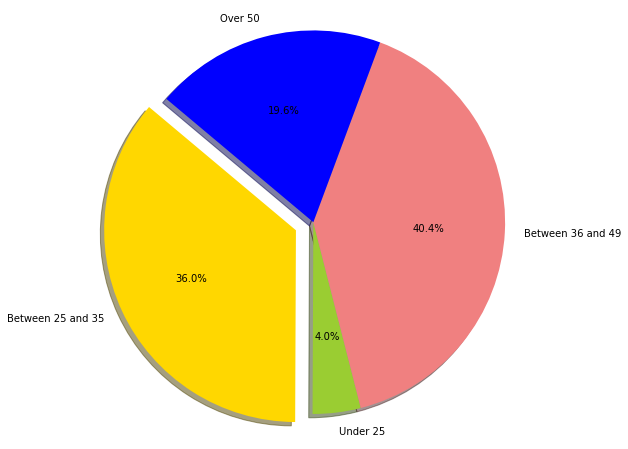

In [17]:
from pyspark.sql import functions as F
from pyspark.sql.window import Window
import matplotlib.pyplot as plt

# First, ensure you've already defined and created the AgeGroup column in bank_df

# Define window for calculating percentages
window = Window.rowsBetween(Window.unboundedPreceding, Window.unboundedFollowing)

# Create the aggregation DataFrame
tab = data.groupBy('Age_udf').agg(
    F.count('*').alias('UserCount')
).withColumn('total', F.sum('UserCount').over(window))\
.withColumn('Percent', F.col('UserCount') * 100 / F.col('total'))

# Collect the data into Pandas DataFrame for plotting
tab_df = tab.toPandas()

# Data to plot
labels = tab_df['Age_udf']
sizes = tab_df['Percent']
colors = ['gold', 'yellowgreen', 'lightcoral', 'blue', 'lightskyblue', 'green', 'red']


explode = (0.1, 0, 0, 0)  # Only "explode" the first slice

# Plot
plt.figure(figsize=(10, 8))
plt.pie(sizes, explode=explode, labels=labels, colors=colors,
        autopct='%1.1f%%', shadow=True, startangle=140)

plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()


In [18]:
# Correlation analysis for numerical columns
numeric_cols = [col for col, dtype in data.dtypes if dtype != "string"]
corr_matrix = data.select(numeric_cols).toPandas().corr()
print("Correlation Matrix:")
print(corr_matrix)


Correlation Matrix:
                     age  duration  campaign     pdays  previous  \
age             1.000000 -0.000866  0.004594 -0.034369  0.024365   
duration       -0.000866  1.000000 -0.071699 -0.047577  0.020640   
campaign        0.004594 -0.071699  1.000000  0.052584 -0.079141   
pdays          -0.034369 -0.047577  0.052584  1.000000 -0.587514   
previous        0.024365  0.020640 -0.079141 -0.587514  1.000000   
emp_var_rate   -0.000371 -0.027968  0.150754  0.271004 -0.420489   
cons_price_idx  0.000857  0.005312  0.127836  0.078889 -0.203130   
cons_conf_idx   0.129372 -0.008173 -0.013733 -0.091342 -0.050936   
euribor_3m      0.010767 -0.032897  0.135133  0.296899 -0.454494   
nr_employed    -0.017725 -0.044703  0.144095  0.372605 -0.501333   
y               0.030399  0.405274 -0.066357 -0.324914  0.230181   

                emp_var_rate  cons_price_idx  cons_conf_idx  euribor_3m  \
age                -0.000371        0.000857       0.129372    0.010767   
duration     

In [19]:
# Handling missing data
missing_count = data.select([F.count(F.when(F.isnan(c) | F.isnull(c), c)).alias(c) for c in data.columns])
missing_count.show()

+---+---+-------+---------+-------+-------+----+-------+-----+-----------+--------+--------+-----+--------+--------+------------+--------------+-------------+----------+-----------+---+-------+
|age|job|marital|education|default|housing|loan|contact|month|day_of_week|duration|campaign|pdays|previous|poutcome|emp_var_rate|cons_price_idx|cons_conf_idx|euribor_3m|nr_employed|  y|Age_udf|
+---+---+-------+---------+-------+-------+----+-------+-----+-----------+--------+--------+-----+--------+--------+------------+--------------+-------------+----------+-----------+---+-------+
|  0|  0|      0|        0|      0|      0|   0|      0|    0|          0|       0|       0|    0|       0|       0|           0|             0|            0|         0|          0|  0|      0|
+---+---+-------+---------+-------+-------+----+-------+-----+-----------+--------+--------+-----+--------+--------+------------+--------------+-------------+----------+-----------+---+-------+



# Prepare data for machine learning

## Applyinh estimators and transformers and create new data frames

### StringIndexer 

In [20]:
data.show(5)

+---+---------+-------+-----------+-------+-------+----+---------+-----+-----------+--------+--------+-----+--------+-----------+------------+--------------+-------------+----------+-----------+---+-----------------+
|age|      job|marital|  education|default|housing|loan|  contact|month|day_of_week|duration|campaign|pdays|previous|   poutcome|emp_var_rate|cons_price_idx|cons_conf_idx|euribor_3m|nr_employed|  y|          Age_udf|
+---+---------+-------+-----------+-------+-------+----+---------+-----+-----------+--------+--------+-----+--------+-----------+------------+--------------+-------------+----------+-----------+---+-----------------+
| 56|housemaid|married|   basic.4y|     no|     no|  no|telephone|  may|        mon|     261|       1|  999|       0|nonexistent|         1.1|        93.994|        -36.4|     4.857|     5191.0|  0|          Over 50|
| 57| services|married|high.school|unknown|     no|  no|telephone|  may|        mon|     149|       1|  999|       0|nonexistent|   

In [21]:
from pyspark.ml.feature import OneHotEncoder, StringIndexer
from pyspark.ml import Pipeline

# List of categorical columns
categorical_columns = ['job', 'marital', 'education', 'Age_udf', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']

# Indexers for categorical columns
indexers = [StringIndexer(inputCol=column, outputCol=column + "_index", handleInvalid="keep").fit(data) for column in categorical_columns]

# Encoder for indexed categorical columns
encoder = [OneHotEncoder(inputCol=column + "_index", outputCol=column + "_encoded") for column in categorical_columns]

# Pipeline for indexing and encoding
pipeline = Pipeline(stages=indexers + encoder)
transformed_data = pipeline.fit(data).transform(data)

# Selecting relevant columns
selected_cols = ['Age_udf_index', 'job_index', 'marital_index', 'education_index', 'default_index', 'housing_index', 'loan_index', 'contact_index', 'month_index', 'day_of_week_index', 'poutcome_index', 'duration', 'campaign', 'pdays', 'previous', 'emp_var_rate', 'cons_price_idx', 'cons_conf_idx', 'euribor_3m', 'nr_employed', 'y']
final_data = transformed_data.select(selected_cols)

final_data.show()

+-------------+---------+-------------+---------------+-------------+-------------+----------+-------------+-----------+-----------------+--------------+--------+--------+-----+--------+------------+--------------+-------------+----------+-----------+---+
|Age_udf_index|job_index|marital_index|education_index|default_index|housing_index|loan_index|contact_index|month_index|day_of_week_index|poutcome_index|duration|campaign|pdays|previous|emp_var_rate|cons_price_idx|cons_conf_idx|euribor_3m|nr_employed|  y|
+-------------+---------+-------------+---------------+-------------+-------------+----------+-------------+-----------+-----------------+--------------+--------+--------+-----+--------+------------+--------------+-------------+----------+-----------+---+
|          2.0|      8.0|          0.0|            4.0|          0.0|          1.0|       0.0|          1.0|        0.0|              1.0|           0.0|     261|       1|  999|       0|         1.1|        93.994|        -36.4|    

## OneHotEncoderEstimator

### Vector Assembler

In [22]:
from pyspark.ml.feature import OneHotEncoder, StringIndexer, VectorAssembler
from pyspark.ml import Pipeline

# Selecting relevant columns along with encoded columns
selected_cols = ['Age_udf_index', 'job_index', 'marital_index', 'education_index', 'default_index', 'housing_index', 'loan_index', 'contact_index', 'month_index', 'day_of_week_index', 'poutcome_index', 'duration', 'campaign', 'pdays', 'previous', 'emp_var_rate', 'cons_price_idx', 'cons_conf_idx', 'euribor_3m', 'nr_employed', 'y']

# Applying VectorAssembler
input_cols = [col + "_index" for col in categorical_columns] + ['duration', 'campaign', 'pdays', 'previous', 'emp_var_rate', 'cons_price_idx', 'cons_conf_idx', 'euribor_3m', 'nr_employed']
assembler = VectorAssembler(inputCols=input_cols, outputCol="vectorized_features")
assembled_data = assembler.transform(transformed_data).select(selected_cols + ["vectorized_features"])

assembled_data.show()

+-------------+---------+-------------+---------------+-------------+-------------+----------+-------------+-----------+-----------------+--------------+--------+--------+-----+--------+------------+--------------+-------------+----------+-----------+---+--------------------+
|Age_udf_index|job_index|marital_index|education_index|default_index|housing_index|loan_index|contact_index|month_index|day_of_week_index|poutcome_index|duration|campaign|pdays|previous|emp_var_rate|cons_price_idx|cons_conf_idx|euribor_3m|nr_employed|  y| vectorized_features|
+-------------+---------+-------------+---------------+-------------+-------------+----------+-------------+-----------+-----------------+--------------+--------+--------+-----+--------+------------+--------------+-------------+----------+-----------+---+--------------------+
|          2.0|      8.0|          0.0|            4.0|          0.0|          1.0|       0.0|          1.0|        0.0|              1.0|           0.0|     261|       

### LabelIndexer 

In [23]:
from pyspark.ml.feature import StringIndexer


label_indexer = StringIndexer()\
    .setInputCol("y")\
    .setOutputCol("label")

label_indexer_model = label_indexer.fit(assembled_data)
label_indexer_df = label_indexer_model.transform(assembled_data)

label_indexer_df.select("y", "label").show(500)


+---+-----+
|  y|label|
+---+-----+
|  0|  0.0|
|  0|  0.0|
|  0|  0.0|
|  0|  0.0|
|  0|  0.0|
|  0|  0.0|
|  0|  0.0|
|  0|  0.0|
|  0|  0.0|
|  0|  0.0|
|  0|  0.0|
|  0|  0.0|
|  0|  0.0|
|  0|  0.0|
|  0|  0.0|
|  0|  0.0|
|  0|  0.0|
|  0|  0.0|
|  0|  0.0|
|  0|  0.0|
|  0|  0.0|
|  0|  0.0|
|  0|  0.0|
|  0|  0.0|
|  0|  0.0|
|  0|  0.0|
|  0|  0.0|
|  0|  0.0|
|  0|  0.0|
|  0|  0.0|
|  0|  0.0|
|  0|  0.0|
|  0|  0.0|
|  0|  0.0|
|  0|  0.0|
|  0|  0.0|
|  0|  0.0|
|  0|  0.0|
|  0|  0.0|
|  0|  0.0|
|  0|  0.0|
|  0|  0.0|
|  0|  0.0|
|  0|  0.0|
|  0|  0.0|
|  0|  0.0|
|  0|  0.0|
|  0|  0.0|
|  0|  0.0|
|  0|  0.0|
|  0|  0.0|
|  0|  0.0|
|  0|  0.0|
|  0|  0.0|
|  0|  0.0|
|  0|  0.0|
|  0|  0.0|
|  0|  0.0|
|  0|  0.0|
|  0|  0.0|
|  0|  0.0|
|  0|  0.0|
|  0|  0.0|
|  0|  0.0|
|  0|  0.0|
|  0|  0.0|
|  0|  0.0|
|  0|  0.0|
|  0|  0.0|
|  0|  0.0|
|  0|  0.0|
|  0|  0.0|
|  0|  0.0|
|  0|  0.0|
|  0|  0.0|
|  1|  1.0|
|  0|  0.0|
|  0|  0.0|
|  0|  0.0|
|  0|  0.0|
|  0

### Standard Scalar 

In [24]:
from pyspark.ml.feature import StandardScaler


scaler = StandardScaler()\
    .setInputCol("vectorized_features")\
    .setOutputCol("features")

scaler_model = scaler.fit(label_indexer_df)
scaler_df = scaler_model.transform(label_indexer_df)

scaler_df.select("vectorized_features", "features").show(5)


+--------------------+--------------------+
| vectorized_features|            features|
+--------------------+--------------------+
|[8.0,0.0,4.0,2.0,...|[2.96157369144451...|
|[3.0,0.0,1.0,2.0,...|[1.11059013429169...|
|(20,[0,2,7,9,11,1...|(20,[0,2,7,9,11,1...|
|(20,[2,5,7,9,11,1...|(20,[2,5,7,9,11,1...|
|[3.0,0.0,1.0,2.0,...|[1.11059013429169...|
+--------------------+--------------------+
only showing top 5 rows



In [25]:
# Joining the features column from scaler_df with label_indexer_df
result_df = assembled_data.join(scaler_df.select("vectorized_features", "features"), on="vectorized_features", how="inner")

# Displaying the first few rows to verify the join
result_df.show(5)


+--------------------+-------------+---------+-------------+---------------+-------------+-------------+----------+-------------+-----------+-----------------+--------------+--------+--------+-----+--------+------------+--------------+-------------+----------+-----------+---+--------------------+
| vectorized_features|Age_udf_index|job_index|marital_index|education_index|default_index|housing_index|loan_index|contact_index|month_index|day_of_week_index|poutcome_index|duration|campaign|pdays|previous|emp_var_rate|cons_price_idx|cons_conf_idx|euribor_3m|nr_employed|  y|            features|
+--------------------+-------------+---------+-------------+---------------+-------------+-------------+----------+-------------+-----------+-----------------+--------------+--------+--------+-----+--------+------------+--------------+-------------+----------+-----------+---+--------------------+
|[8.0,0.0,4.0,2.0,...|          2.0|      8.0|          0.0|            4.0|          0.0|          1.0|  

# Train / Test split

In [26]:
train, test = result_df.randomSplit([0.8, 0.2], seed = 2018)
print("Training Dataset Count: " + str(train.count()))
print("Test Dataset Count: " + str(test.count()))

Training Dataset Count: 33008
Test Dataset Count: 8238


# Model Training

## 1. Logistic Regression 

In [27]:
from pyspark.ml.classification import LogisticRegression


lr = LogisticRegression(featuresCol='features', labelCol='y', maxIter=5)  # 'y' is your label column
lrModel = lr.fit(train)  # Training the Logistic Regression model on the 'train' data
predictions = lrModel.transform(test)  # Making predictions on the 'test' data

# Selecting columns to display from predictions
selected_cols = ['features', 'rawPrediction', 'prediction', 'probability']
predictions.select(selected_cols).show(5)  # Displaying the selected columns for the first five rows



+--------------------+--------------------+----------+--------------------+
|            features|       rawPrediction|prediction|         probability|
+--------------------+--------------------+----------+--------------------+
|(20,[0,1,2,3,11,1...|[3.20327205686813...|       0.0|[0.96095722499159...|
|(20,[0,1,2,3,11,1...|[2.53681190158090...|       0.0|[0.92668251512804...|
|(20,[0,1,2,3,11,1...|[2.39802529003645...|       0.0|[0.91667659800098...|
|(20,[0,1,2,3,11,1...|[2.28103226644206...|       0.0|[0.90729390905112...|
|(20,[0,1,2,3,11,1...|[2.64095480517181...|       0.0|[0.93345130144564...|
+--------------------+--------------------+----------+--------------------+
only showing top 5 rows



Confusion matrix, without normalization
[[ 348  601]
 [ 179 7110]]


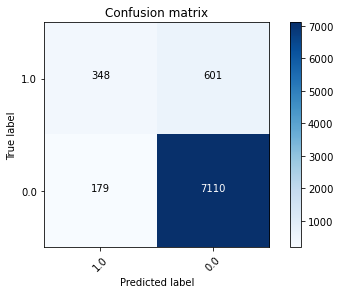

In [28]:
from sklearn.metrics import confusion_matrix
import itertools
import numpy as np
import matplotlib.pyplot as plt


y_true = predictions.select("y").rdd.map(lambda row: row.y).collect()
y_pred = predictions.select("prediction").rdd.map(lambda row: row.prediction).collect()

class_names = [1.0, 0.0]  # Replace with your actual class labels

def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion matrix',
                          cmap=plt.cm.Blues):
    """
    This function prints and plots the confusion matrix.
    Normalization can be applied by setting `normalize=True`.
    """
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Normalized confusion matrix")
    else:
        print('Confusion matrix, without normalization')

    print(cm)

    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')

# Generate confusion matrix
cnf_matrix = confusion_matrix(y_true, y_pred, labels=class_names)

# Plot confusion matrix
plt.figure()
plot_confusion_matrix(cnf_matrix, classes=class_names, title='Confusion matrix')
plt.show()


Accuracy: 0.9053168244719592


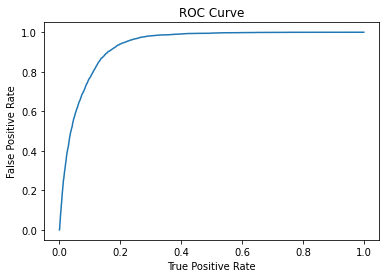

Training set areaUnderROC: 0.9335951421525324


In [29]:

accuracy = predictions.filter(predictions.y == predictions.prediction).count() / float(predictions.count())
print("Accuracy:", accuracy)

# Accessing model summary
trainingSummary = lrModel.summary

# Converting ROC curve to Pandas DataFrame
roc = trainingSummary.roc.toPandas()

# Plotting ROC curve
import matplotlib.pyplot as plt

plt.plot(roc['FPR'], roc['TPR'])
plt.ylabel('False Positive Rate')
plt.xlabel('True Positive Rate')
plt.title('ROC Curve')
plt.show()

# Area under ROC curve
print('Training set areaUnderROC:', trainingSummary.areaUnderROC)


## 2. Random forest model 

In [30]:
from pyspark.ml.classification import RandomForestClassifier
from pyspark.ml.evaluation import BinaryClassificationEvaluator

rf = RandomForestClassifier(featuresCol='features', labelCol='y')
rfModel = rf.fit(train)
predictions_rf = rfModel.transform(test)

# Selecting columns to display from predictions
selected_cols_rf = ['features', 'rawPrediction', 'prediction', 'probability']
predictions_rf.select(selected_cols_rf).show(5)

# Calculating AUC for Random Forest
evaluator_rf = BinaryClassificationEvaluator(labelCol='y')
auc_rf = evaluator_rf.evaluate(predictions_rf)
print("AUC for Random Forest:", auc_rf)


+--------------------+--------------------+----------+--------------------+
|            features|       rawPrediction|prediction|         probability|
+--------------------+--------------------+----------+--------------------+
|(20,[0,1,2,3,11,1...|[18.7625625313551...|       0.0|[0.93812812656775...|
|(20,[0,1,2,3,11,1...|[18.7625625313551...|       0.0|[0.93812812656775...|
|(20,[0,1,2,3,11,1...|[18.7456182317603...|       0.0|[0.93728091158801...|
|(20,[0,1,2,3,11,1...|[18.7456182317603...|       0.0|[0.93728091158801...|
|(20,[0,1,2,3,11,1...|[18.7456182317603...|       0.0|[0.93728091158801...|
+--------------------+--------------------+----------+--------------------+
only showing top 5 rows

AUC for Random Forest: 0.9295743647666325


Confusion matrix, without normalization
[[ 185  764]
 [  42 7247]]


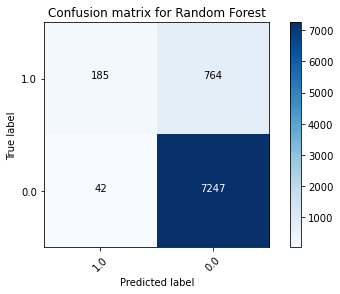

In [31]:
from sklearn.metrics import confusion_matrix
import itertools
import numpy as np
import matplotlib.pyplot as plt


y_true_rf = predictions_rf.select("y").rdd.map(lambda row: row.y).collect()
y_pred_rf = predictions_rf.select("prediction").rdd.map(lambda row: row.prediction).collect()

class_names_rf = [1.0, 0.0]  # Replace with your actual class labels for Random Forest

def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion matrix',
                          cmap=plt.cm.Blues):
    """
    This function prints and plots the confusion matrix.
    Normalization can be applied by setting `normalize=True`.
    """
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Normalized confusion matrix")
    else:
        print('Confusion matrix, without normalization')

    print(cm)

    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')

# Generate confusion matrix for Random Forest
cnf_matrix_rf = confusion_matrix(y_true_rf, y_pred_rf, labels=class_names_rf)

# Plot confusion matrix for Random Forest
plt.figure()
plot_confusion_matrix(cnf_matrix_rf, classes=class_names_rf, title='Confusion matrix for Random Forest')
plt.show()


AUC for Random Forest: 0.9295743647666324


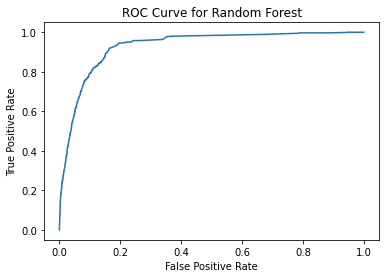

In [32]:
from sklearn.metrics import roc_curve, auc



# Accessing probabilities for the positive class
rf_probabilities = predictions_rf.select('y', 'probability').rdd.map(lambda row: (float(row['probability'][1]), float(row['y']))).collect()

# Unpacking probabilities and actual labels
rf_probabilities, actual_labels = zip(*rf_probabilities)

# Calculating FPR and TPR for the ROC curve
fpr_rf, tpr_rf, _ = roc_curve(actual_labels, rf_probabilities)

# Calculating AUC for Random Forest
auc_rf = auc(fpr_rf, tpr_rf)
print("AUC for Random Forest:", auc_rf)

# Plotting ROC curve for Random Forest
plt.plot(fpr_rf, tpr_rf)
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.title('ROC Curve for Random Forest')
plt.show()


## 3. GBT classifier

In [33]:
from pyspark.ml.classification import GBTClassifier

gbt = GBTClassifier(featuresCol='features', labelCol='y', maxIter=10)
gbtModel = gbt.fit(train)
predictions_gbt = gbtModel.transform(test)

# Selecting columns to display from predictions
selected_cols_gbt = ['features', 'rawPrediction', 'prediction', 'probability']
predictions_gbt.select(selected_cols_gbt).show(5)

# Calculating AUC for Gradient-Boosted Trees
evaluator_gbt = BinaryClassificationEvaluator(labelCol='y')
auc_gbt = evaluator_gbt.evaluate(predictions_gbt)
print("AUC for Gradient-Boosted Trees:", auc_gbt)

+--------------------+--------------------+----------+--------------------+
|            features|       rawPrediction|prediction|         probability|
+--------------------+--------------------+----------+--------------------+
|(20,[0,1,2,3,11,1...|[1.27947814881911...|       0.0|[0.92817290731479...|
|(20,[0,1,2,3,11,1...|[1.27947814881911...|       0.0|[0.92817290731479...|
|(20,[0,1,2,3,11,1...|[1.30201836009212...|       0.0|[0.93112092467938...|
|(20,[0,1,2,3,11,1...|[1.30201836009212...|       0.0|[0.93112092467938...|
|(20,[0,1,2,3,11,1...|[1.27947814881911...|       0.0|[0.92817290731479...|
+--------------------+--------------------+----------+--------------------+
only showing top 5 rows

AUC for Gradient-Boosted Trees: 0.9445752444500791


Confusion matrix, without normalization
[[ 525  424]
 [ 272 7017]]


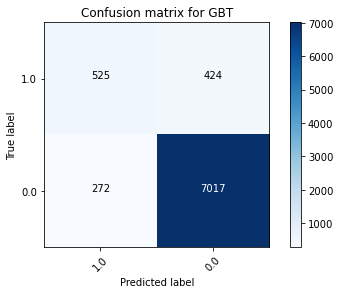

In [34]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

y_true_gbt = predictions_gbt.select("y").rdd.map(lambda row: row.y).collect()
y_pred_gbt = predictions_gbt.select("prediction").rdd.map(lambda row: row.prediction).collect()

class_names_gbt = [1.0, 0.0]  # Replace with your actual class labels

# Function to plot confusion matrix
def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion matrix',
                          cmap=plt.cm.Blues):
    """
    This function prints and plots the confusion matrix.
    Normalization can be applied by setting `normalize=True`.
    """
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Normalized confusion matrix")
    else:
        print('Confusion matrix, without normalization')

    print(cm)

    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')

# Generate confusion matrix
cnf_matrix_gbt = confusion_matrix(y_true_gbt, y_pred_gbt, labels=class_names_gbt)

# Plot confusion matrix
plt.figure()
plot_confusion_matrix(cnf_matrix_gbt, classes=class_names_gbt, title='Confusion matrix for GBT')
plt.show()


AUC for Gradient-Boosted Trees: 0.9445752444500793


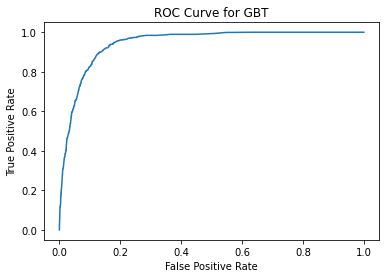

In [35]:
# Calculating AUC for Gradient-Boosted Trees
from sklearn.metrics import roc_curve, auc

gbt_probabilities = predictions_gbt.select('y', 'probability').rdd.map(lambda row: (float(row['probability'][1]), float(row['y']))).collect()

# Unpacking probabilities and actual labels
gbt_probabilities, gbt_actual_labels = zip(*gbt_probabilities)

# Calculating FPR and TPR for the ROC curve
fpr_gbt, tpr_gbt, _ = roc_curve(gbt_actual_labels, gbt_probabilities)

# Calculating AUC for GBT
auc_gbt = auc(fpr_gbt, tpr_gbt)
print("AUC for Gradient-Boosted Trees:", auc_gbt)

# Plotting ROC curve for GBT
plt.plot(fpr_gbt, tpr_gbt)
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.title('ROC Curve for GBT')
plt.show()


## 4. Decision tree model 

In [36]:
from pyspark.ml.classification import DecisionTreeClassifier

dt = DecisionTreeClassifier(featuresCol='features', labelCol='y')
dtModel = dt.fit(train)
predictions_dt = dtModel.transform(test)

# Selecting columns to display from predictions
selected_cols_dt = ['features', 'rawPrediction', 'prediction', 'probability']
predictions_dt.select(selected_cols_dt).show(5)

# Calculating AUC for Decision Trees
evaluator_dt = BinaryClassificationEvaluator(labelCol='y')
auc_dt = evaluator_dt.evaluate(predictions_dt)
print("AUC for Decision Trees:", auc_dt)


+--------------------+---------------+----------+--------------------+
|            features|  rawPrediction|prediction|         probability|
+--------------------+---------------+----------+--------------------+
|(20,[0,1,2,3,11,1...|[24033.0,414.0]|       0.0|[0.98306540679838...|
|(20,[0,1,2,3,11,1...|[24033.0,414.0]|       0.0|[0.98306540679838...|
|(20,[0,1,2,3,11,1...|[24033.0,414.0]|       0.0|[0.98306540679838...|
|(20,[0,1,2,3,11,1...|[24033.0,414.0]|       0.0|[0.98306540679838...|
|(20,[0,1,2,3,11,1...|[24033.0,414.0]|       0.0|[0.98306540679838...|
+--------------------+---------------+----------+--------------------+
only showing top 5 rows

AUC for Decision Trees: 0.642619022182335


Confusion matrix, without normalization
[[ 525  424]
 [ 272 7017]]


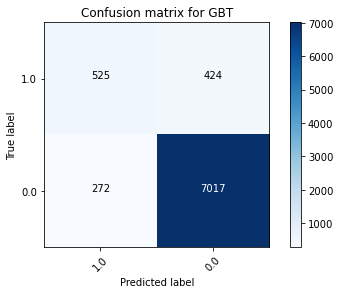

In [37]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

y_true_gbt = predictions_gbt.select("y").rdd.map(lambda row: row.y).collect()
y_pred_gbt = predictions_gbt.select("prediction").rdd.map(lambda row: row.prediction).collect()

class_names_gbt = [1.0, 0.0]  # Replace with your actual class labels

# Function to plot confusion matrix
def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion matrix',
                          cmap=plt.cm.Blues):
    """
    This function prints and plots the confusion matrix.
    Normalization can be applied by setting `normalize=True`.
    """
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Normalized confusion matrix")
    else:
        print('Confusion matrix, without normalization')

    print(cm)

    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')

# Generate confusion matrix
cnf_matrix_gbt = confusion_matrix(y_true_gbt, y_pred_gbt, labels=class_names_gbt)

# Plot confusion matrix
plt.figure()
plot_confusion_matrix(cnf_matrix_gbt, classes=class_names_gbt, title='Confusion matrix for GBT')
plt.show()


AUC for Gradient-Boosted Trees: 0.9445752444500793


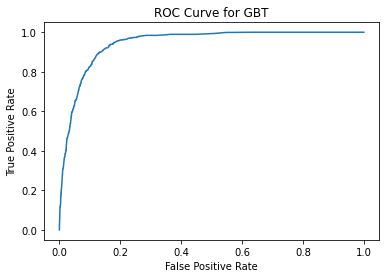

In [38]:
# Calculating AUC for Gradient-Boosted Trees
from sklearn.metrics import roc_curve, auc

gbt_probabilities = predictions_gbt.select('y', 'probability').rdd.map(lambda row: (float(row['probability'][1]), float(row['y']))).collect()

# Unpacking probabilities and actual labels
gbt_probabilities, gbt_actual_labels = zip(*gbt_probabilities)

# Calculating FPR and TPR for the ROC curve
fpr_gbt, tpr_gbt, _ = roc_curve(gbt_actual_labels, gbt_probabilities)

# Calculating AUC for GBT
auc_gbt = auc(fpr_gbt, tpr_gbt)
print("AUC for Gradient-Boosted Trees:", auc_gbt)

# Plotting ROC curve for GBT
plt.plot(fpr_gbt, tpr_gbt)
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.title('ROC Curve for GBT')
plt.show()


## 5. SVM model

In [39]:
from pyspark.ml.classification import LinearSVC
from pyspark.ml.evaluation import BinaryClassificationEvaluator


svm = LinearSVC(featuresCol='features', labelCol='y', maxIter=10, regParam=0.1)
svm_model = svm.fit(train)
predictions_svm = svm_model.transform(test)

# Selecting columns to display from predictions
selected_cols_svm = ['features', 'rawPrediction', 'prediction']
predictions_svm.select(selected_cols_svm).show(5)

# Evaluating the model using BinaryClassificationEvaluator
evaluator_svm = BinaryClassificationEvaluator(labelCol='y')
auc_svm = evaluator_svm.evaluate(predictions_svm)
print("AUC for Support Vector Machines:", auc_svm)


+--------------------+--------------------+----------+
|            features|       rawPrediction|prediction|
+--------------------+--------------------+----------+
|(20,[0,1,2,3,11,1...|[1.37153387849145...|       0.0|
|(20,[0,1,2,3,11,1...|[1.15575642177240...|       0.0|
|(20,[0,1,2,3,11,1...|[1.14022903265313...|       0.0|
|(20,[0,1,2,3,11,1...|[1.10345813846051...|       0.0|
|(20,[0,1,2,3,11,1...|[1.21717014747249...|       0.0|
+--------------------+--------------------+----------+
only showing top 5 rows

AUC for Support Vector Machines: 0.915486057270356


Confusion matrix, without normalization
[[ 525  424]
 [ 272 7017]]


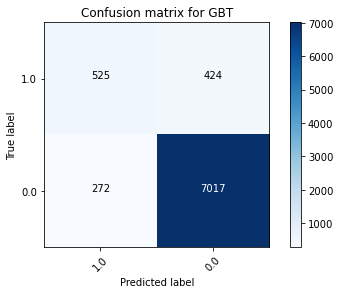

In [40]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np


y_true_gbt = predictions_gbt.select("y").rdd.map(lambda row: row.y).collect()
y_pred_gbt = predictions_gbt.select("prediction").rdd.map(lambda row: row.prediction).collect()

class_names_gbt = [1.0, 0.0]  # Replace with your actual class labels

# Function to plot confusion matrix
def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion matrix',
                          cmap=plt.cm.Blues):
    """
    This function prints and plots the confusion matrix.
    Normalization can be applied by setting `normalize=True`.
    """
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Normalized confusion matrix")
    else:
        print('Confusion matrix, without normalization')

    print(cm)

    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')

# Generate confusion matrix
cnf_matrix_gbt = confusion_matrix(y_true_gbt, y_pred_gbt, labels=class_names_gbt)

# Plot confusion matrix
plt.figure()
plot_confusion_matrix(cnf_matrix_gbt, classes=class_names_gbt, title='Confusion matrix for GBT')
plt.show()


AUC for Gradient-Boosted Trees: 0.9445752444500793


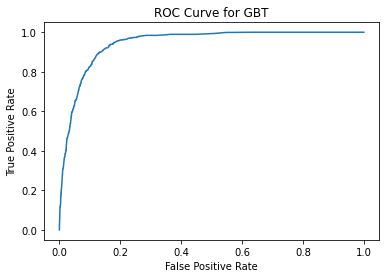

In [41]:
# Calculating AUC for Gradient-Boosted Trees
from sklearn.metrics import roc_curve, auc

gbt_probabilities = predictions_gbt.select('y', 'probability').rdd.map(lambda row: (float(row['probability'][1]), float(row['y']))).collect()

# Unpacking probabilities and actual labels
gbt_probabilities, gbt_actual_labels = zip(*gbt_probabilities)

# Calculating FPR and TPR for the ROC curve
fpr_gbt, tpr_gbt, _ = roc_curve(gbt_actual_labels, gbt_probabilities)

# Calculating AUC for GBT
auc_gbt = auc(fpr_gbt, tpr_gbt)
print("AUC for Gradient-Boosted Trees:", auc_gbt)

# Plotting ROC curve for GBT
plt.plot(fpr_gbt, tpr_gbt)
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.title('ROC Curve for GBT')
plt.show()


In [42]:
from pyspark.ml.feature import VectorAssembler, StandardScaler
from pyspark.ml.clustering import KMeans

# Step 1: Assemble features into a single vector
assembler = VectorAssembler(inputCols=['age', 'duration', 'campaign', 'pdays', 'previous', 'emp_var_rate', 'cons_price_idx', 'cons_conf_idx', 'euribor_3m', 'nr_employed'], outputCol='features')
assembled_data = assembler.transform(data)

# Step 2: Scale the features
scaler = StandardScaler(inputCol='features', outputCol='scaled_features')
scaler_model = scaler.fit(assembled_data)
scaled_data = scaler_model.transform(assembled_data)

# Step 3: Apply K-means clustering
kmeans = KMeans(featuresCol='scaled_features', predictionCol='cluster', k=3, seed=42)
model = kmeans.fit(scaled_data)

# Make predictions on the data
predictions = model.transform(scaled_data)

# Step 4: Analyze results (e.g., display predictions)
predictions.select('features', 'cluster').show(5)

# Optionally, view cluster centers
cluster_centers = model.clusterCenters()
print("Cluster Centers:")
for center in cluster_centers:
    print(center)

# Stop the SparkSession
spark.stop()


+--------------------+-------+
|            features|cluster|
+--------------------+-------+
|[56.0,261.0,1.0,9...|      0|
|[57.0,149.0,1.0,9...|      0|
|[37.0,226.0,1.0,9...|      0|
|[40.0,151.0,1.0,9...|      0|
|[56.0,307.0,1.0,9...|      0|
+--------------------+-------+
only showing top 5 rows

Cluster Centers:
[ 3.85681543e+00  9.73438921e-01  1.01116491e+00  5.34479242e+00
  5.10176473e-02  7.11551509e-01  1.62123994e+02 -8.52529726e+00
  2.77811622e+00  7.21565320e+01]
[  3.78009533   1.01681813   0.76707283   5.34479242   0.64239205
  -1.2893988  160.6429563   -9.33180955   0.69323107  70.28190653]
[ 4.02162789e+00  1.24316398e+00  6.60599705e-01  1.18422279e-01
  3.42453323e+00 -1.32940489e+00  1.61275354e+02 -8.28290757e+00
  5.66934563e-01  6.95977105e+01]


In [ ]:
from pyspark.ml.classification import GBTClassifier


save_path = r"C:\"

# Update the path as needed

gbtModel.write().overwrite().save(save_path)


In [ ]:
os.makedirs(save_path, exist_ok=True)

In [ ]:
# Import SparkContext
from pyspark import SparkContext

# Check if SparkContext is available, otherwise create it
try:
    sc = SparkContext.getOrCreate()
except:
    sc = SparkContext()

In [ ]:
from pyspark.ml.classification import GBTClassifier
# gbt = GBTClassifier(featuresCol = 'features', labelCol = 'label', maxIter=10)
# gbtModel = gbt.fit(train)
gbtModel.write().overwrite().save(save_path)

In [ ]:
lr.write().overwrite().save(save_path)

In [ ]:
gbtModel = gbtModel.load(save_path)

In [ ]:
lr = lr.load(save_path)

In [ ]:
# Later for loading the model
gbtModel = GBTClassificationModel.load(save_path)
